In [1]:
import numpy as np

from gymnasium import utils
from gymnasium.envs.mujoco import MujocoEnv
from gymnasium.spaces import Box


In [2]:
#__credits__ = ["Kallinteris-Andreas", "Rushiv Arora"]
# https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/mujoco/swimmer_v5.py referenced
class ROVEnv(MujocoEnv, utils.EzPickle):

    metadata = {
        "render_modes": [
            "human",
            "rgb_array",
            "depth_array",
            "rgbd_tuple",
        ],
    }

    def __init__(
        self,
        xml_file: str = "rov.xml",
        frame_skip: int = 4,
        default_camera_config: dict[str, float | int] = None,
        distance_reward_weight: float = 1.0,
        energy_cost_weight: float = 1e-4,
        reset_noise_scale: float = 0.1,
        **kwargs,
    ):
        utils.EzPickle.__init__(
            self,
            xml_file,
            frame_skip,
            default_camera_config,
            distance_reward_weight,
            energy_cost_weight,
            reset_noise_scale,
            **kwargs,
        )

        self.distance_reward_weight = distance_reward_weight
        self.energy_cost_weight = energy_cost_weight

        self._reset_noise_scale = reset_noise_scale

        MujocoEnv.__init__(
            self,
            xml_file,
            frame_skip,
            observation_space=None,
            default_camera_config=default_camera_config,
            **kwargs,
        )

        self.metadata = {
            "render_modes": [
                "human",
                "rgb_array",
                "depth_array",
                "rgbd_tuple",
            ],
            "render_fps": int(np.round(1.0 / self.dt)),
        }

        obs_size = 4
        
        self.observation_space = Box(
            low=-np.inf, high=np.inf, shape=(obs_size,), dtype=np.float64
        )

        self.observation_structure = {
            "distance_to_goal": 2,
            "velocity": 2,
        }

    def step(self, action):        
        xy_position_before = self.data.qpos[0:2].copy()
        self.do_simulation(action, self.frame_skip)
        xy_position_after = self.data.qpos[0:2].copy()

        xy_velocity = (xy_position_after - xy_position_before) / self.dt
        x_velocity, y_velocity = xy_velocity

        observation = self.get_observation()
        
        reward, reward_info = self.get_reward(xy_position_after, action)
        info = {
            "x_position": xy_position_after[0],
            "y_position": xy_position_after[1],
            "distance_from_origin": np.linalg.norm(xy_position_after, ord=2),
            "x_velocity": x_velocity,
            "y_velocity": y_velocity,
            **reward_info,
        }

        if self.render_mode == "human":
            self.render()

        distance_to_goal = np.linalg.norm(observation[0:2])
        if distance_to_goal < 0.5:
            terminated = True
        else:
            terminated = False

        self.step_count += 1
        if self.step_count >= 1000:
            truncated = True
        else:
            truncated = False

        return observation, reward, terminated, truncated, info

    def get_reward(self, position, action):
        distance_from_goal = self.goal_position - position
        distance_reward = self.distance_reward_weight * np.exp(-np.linalg.norm(distance_from_goal)**2)
        energy_reward = self.energy_cost_weight * np.exp(-np.linalg.norm(action)**2)
        total_reward = distance_reward + energy_reward

        reward = total_reward

        reward_info = {
            "distance_reward": distance_reward,
            "energy_reward": energy_reward,
            "total_reward": total_reward,
        }

        return reward, reward_info

    def get_observation(self):
        position = self.data.qpos[0:2]
        distance_to_goal = self.goal_position - position
        velocity = self.data.qvel[0:2]

        observation = np.concatenate([distance_to_goal, velocity]).ravel()
        return observation

    def reset_model(self):
        self.step_count = 0
        
        noise_low = -self._reset_noise_scale
        noise_high = self._reset_noise_scale

        qpos = self.init_qpos + self.np_random.uniform(
            low=noise_low, high=noise_high, size=self.model.nq
        )
        qvel = self.init_qvel + self.np_random.uniform(
            low=noise_low, high=noise_high, size=self.model.nv
        )

        self.set_state(qpos, qvel)

        self.goal_position = self.np_random.uniform(low=-4.8, high=4.8, size=(2, ))
        print(self.goal_position)

        observation = self.get_observation()
        return observation

    def get_reset_info(self):
        return {
            "x_position": self.data.qpos[0],
            "y_position": self.data.qpos[1],
            "distance_from_origin": np.linalg.norm(self.data.qpos[0:2], ord=2),
            "current_goal": self.goal_position,
        }

In [35]:
import os
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor


log_dir = "./logs/"
os.makedirs(log_dir, exist_ok=True)

env = ROVEnv(xml_file="/home/charstieve/cs4180/rov.xml")
check_env(env)
env = Monitor(env, log_dir)

model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=1_000_000)
model.save("rov_ppo")

[3.0073943  3.96245354]
[ 3.03219412 -4.7737104 ]
[3.48651765 0.39802771]
Using cpu device
Wrapping the env in a DummyVecEnv.
[1.63799438 1.41301931]
[1.78120305 1.44440905]
[ 0.2434015  -1.82167799]
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | 7.3      |
| time/              |          |
|    fps             | 4558     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
[ 0.68668638 -1.71005385]
[-2.6192871   1.18259659]
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1e+03        |
|    ep_rew_mean          | 20.7         |
| time/                   |              |
|    fps                  | 3049         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 4096         |
| train/             

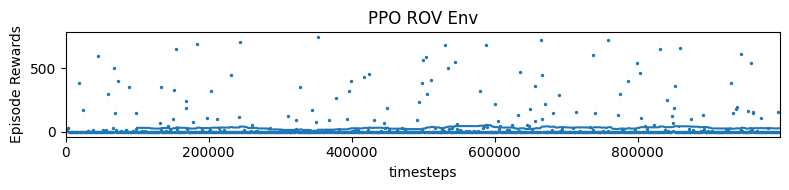

In [36]:
from stable_baselines3.common import results_plotter

results_plotter.plot_results([log_dir], 1000000, results_plotter.X_TIMESTEPS, "PPO ROV Env")
plt.show()

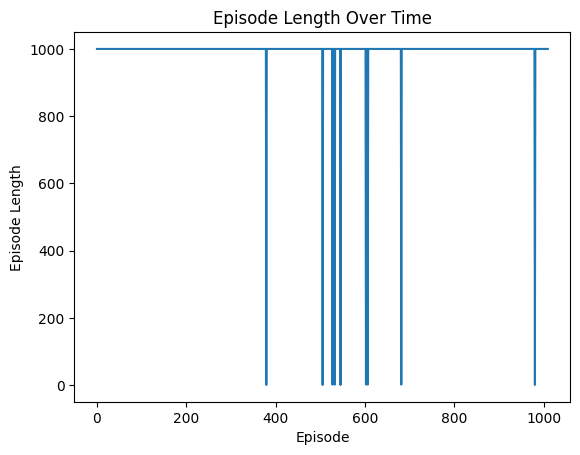

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./logs/monitor.csv", skiprows=1)

plt.plot(df["l"])
plt.xlabel("Episode")
plt.ylabel("Episode Length")
plt.title("Episode Length Over Time")
plt.show()

In [62]:
import pandas as pd

df = pd.read_csv("./logs" + "/monitor.csv", comment="#")
print(df["r"].describe())

count    1010.000000
mean       31.205927
std       108.541614
min         0.007843
25%         0.013250
50%         0.016470
75%         0.921525
max       746.055257
Name: r, dtype: float64


In [47]:
#__credits__ = ["Kallinteris-Andreas", "Rushiv Arora"]
# https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/mujoco/swimmer_v5.py referenced

import numpy as np

from gymnasium import utils
from gymnasium.envs.mujoco import MujocoEnv
from gymnasium.spaces import Box


class ROVEnvV2(MujocoEnv, utils.EzPickle):

    metadata = {
        "render_modes": [
            "human",
            "rgb_array",
            "depth_array",
            "rgbd_tuple",
        ],
    }

    def __init__(
        self,
        xml_file: str = "rovV2.xml",
        frame_skip: int = 4,
        default_camera_config: dict[str, float | int] = None,
        distance_reward_weight: float = 1.0,
        energy_cost_weight: float = 1e-4,
        reset_noise_scale: float = 0.1,
        **kwargs,
    ):
        utils.EzPickle.__init__(
            self,
            xml_file,
            frame_skip,
            default_camera_config,
            distance_reward_weight,
            energy_cost_weight,
            reset_noise_scale,
            **kwargs,
        )

        self.distance_reward_weight = distance_reward_weight
        self.energy_cost_weight = energy_cost_weight

        self._reset_noise_scale = reset_noise_scale

        MujocoEnv.__init__(
            self,
            xml_file,
            frame_skip,
            observation_space=None,
            default_camera_config=default_camera_config,
            **kwargs,
        )

        self.metadata = {
            "render_modes": [
                "human",
                "rgb_array",
                "depth_array",
                "rgbd_tuple",
            ],
            "render_fps": int(np.round(1.0 / self.dt)),
        }

        obs_size = 4
        
        self.observation_space = Box(
            low=-np.inf, high=np.inf, shape=(obs_size,), dtype=np.float64
        )

        self.observation_structure = {
            "distance_to_goal": 2,
            "velocity": 2,
        }

    def step(self, action):        
        xy_position_before = self.data.qpos[0:2].copy()
        self.do_simulation(action, self.frame_skip)
        xy_position_after = self.data.qpos[0:2].copy()

        xy_velocity = (xy_position_after - xy_position_before) / self.dt
        x_velocity, y_velocity = xy_velocity

        observation = self.get_observation()
        
        reward, reward_info = self.get_reward(xy_position_after, action)
        info = {
            "x_position": xy_position_after[0],
            "y_position": xy_position_after[1],
            "distance_from_origin": np.linalg.norm(xy_position_after, ord=2),
            "x_velocity": x_velocity,
            "y_velocity": y_velocity,
            **reward_info,
        }

        if self.render_mode == "human":
            self.render()

        distance_to_goal = np.linalg.norm(observation[0:2])
        if distance_to_goal < 0.5:
            terminated = True
        else:
            terminated = False

        self.step_count += 1
        if self.step_count >= 1000:
            truncated = True
        else:
            truncated = False

        return observation, reward, terminated, truncated, info

    def get_reward(self, position, action):
        distance_from_goal = self.goal_position - position
        distance_reward = self.distance_reward_weight * np.exp(-np.linalg.norm(distance_from_goal)**2)
        energy_reward = self.energy_cost_weight * np.exp(-np.linalg.norm(action)**2)
        reward_bonus = 0

        if distance_from_goal < 1:
            reward_bonus = 10

        total_reward = distance_reward + energy_reward + reward_bonus

        reward = total_reward

        reward_info = {
            "distance_reward": distance_reward,
            "energy_reward": energy_reward,
            "total_reward": total_reward,
        }

        return reward, reward_info

    def get_observation(self):
        position = self.data.qpos[0:2]
        distance_to_goal = self.goal_position - position
        velocity = self.data.qvel[0:2]

        observation = np.concatenate([distance_to_goal, velocity]).ravel()
        return observation

    def reset_model(self):
        self.step_count = 0
        
        noise_low = -self._reset_noise_scale
        noise_high = self._reset_noise_scale

        qpos = self.init_qpos + self.np_random.uniform(
            low=noise_low, high=noise_high, size=self.model.nq
        )
        qvel = self.init_qvel + self.np_random.uniform(
            low=noise_low, high=noise_high, size=self.model.nv
        )

        self.set_state(qpos, qvel)

        self.goal_position = self.np_random.uniform(low=-4.8, high=4.8, size=(2, ))
        print(self.goal_position)

        observation = self.get_observation()
        return observation

    def get_reset_info(self):
        return {
            "x_position": self.data.qpos[0],
            "y_position": self.data.qpos[1],
            "distance_from_origin": np.linalg.norm(self.data.qpos[0:2], ord=2),
            "current_goal": self.goal_position,
        }

In [48]:
import os
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor


log_dir = "./logsV2/"
os.makedirs(log_dir, exist_ok=True)


env = ROVEnv(xml_file="/home/charstieve/cs4180/rovV2.xml")
check_env(env)
env = Monitor(env, log_dir)

model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=1_000_000)
model.save("rov_ppo_v2")

[3.0073943  3.96245354]
[ 3.03219412 -4.7737104 ]
[3.48651765 0.39802771]
Using cpu device
Wrapping the env in a DummyVecEnv.
[1.63799438 1.41301931]
[1.78120305 1.44440905]
[ 0.2434015  -1.82167799]
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | 7.24     |
| time/              |          |
|    fps             | 4476     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
[ 0.68668638 -1.71005385]
[-2.6192871   1.18259659]
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1e+03        |
|    ep_rew_mean          | 18.5         |
| time/                   |              |
|    fps                  | 2922         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 4096         |
| train/             

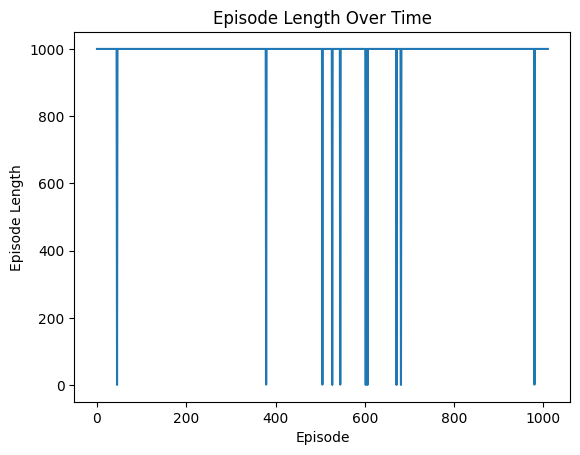

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./logsV2/monitor.csv", skiprows=1)

plt.plot(df["l"])
plt.xlabel("Episode")
plt.ylabel("Episode Length")
plt.title("Episode Length Over Time")
plt.show()

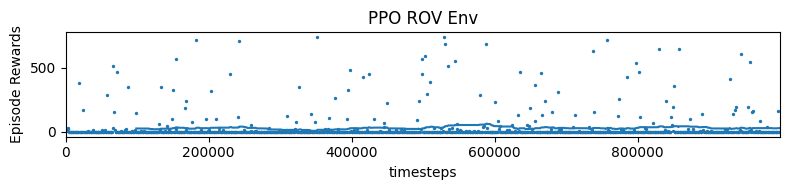

In [50]:
from stable_baselines3.common import results_plotter

results_plotter.plot_results([log_dir], 1000000, results_plotter.X_TIMESTEPS, "PPO ROV Env")
plt.show()

In [63]:
#__credits__ = ["Kallinteris-Andreas", "Rushiv Arora"]
# https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/mujoco/swimmer_v5.py referenced

import numpy as np

from gymnasium import utils
from gymnasium.envs.mujoco import MujocoEnv
from gymnasium.spaces import Box


class ROVEnvV3(MujocoEnv, utils.EzPickle):

    metadata = {
        "render_modes": [
            "human",
            "rgb_array",
            "depth_array",
            "rgbd_tuple",
        ],
    }

    def __init__(
        self,
        xml_file: str = "rovV2.xml",
        frame_skip: int = 4,
        default_camera_config: dict[str, float | int] = None,
        distance_reward_weight: float = 1.0,
        energy_cost_weight: float = 1e-4,
        reset_noise_scale: float = 0.1,
        **kwargs,
    ):
        utils.EzPickle.__init__(
            self,
            xml_file,
            frame_skip,
            default_camera_config,
            distance_reward_weight,
            energy_cost_weight,
            reset_noise_scale,
            **kwargs,
        )

        self.distance_reward_weight = distance_reward_weight
        self.energy_cost_weight = energy_cost_weight

        self._reset_noise_scale = reset_noise_scale

        MujocoEnv.__init__(
            self,
            xml_file,
            frame_skip,
            observation_space=None,
            default_camera_config=default_camera_config,
            **kwargs,
        )

        self.metadata = {
            "render_modes": [
                "human",
                "rgb_array",
                "depth_array",
                "rgbd_tuple",
            ],
            "render_fps": int(np.round(1.0 / self.dt)),
        }

        obs_size = 4
        
        self.observation_space = Box(
            low=-np.inf, high=np.inf, shape=(obs_size,), dtype=np.float64
        )

        self.observation_structure = {
            "distance_to_goal": 2,
            "velocity": 2,
        }

    def step(self, action):        
        xy_position_before = self.data.qpos[0:2].copy()
        self.do_simulation(action, self.frame_skip)
        xy_position_after = self.data.qpos[0:2].copy()

        xy_velocity = (xy_position_after - xy_position_before) / self.dt
        x_velocity, y_velocity = xy_velocity

        observation = self.get_observation()
        
        reward, reward_info = self.get_reward(xy_position_after, action)
        info = {
            "x_position": xy_position_after[0],
            "y_position": xy_position_after[1],
            "distance_from_origin": np.linalg.norm(xy_position_after, ord=2),
            "x_velocity": x_velocity,
            "y_velocity": y_velocity,
            **reward_info,
        }

        if self.render_mode == "human":
            self.render()

        distance_to_goal = np.linalg.norm(observation[0:2])
        if distance_to_goal < 0.5:
            terminated = True
        else:
            terminated = False

        self.step_count += 1
        if self.step_count >= 1000:
            truncated = True
        else:
            truncated = False

        return observation, reward, terminated, truncated, info

    def get_reward(self, position, action):
        distance_from_goal = np.linalg.norm(self.goal_position - position)

        if not hasattr(self, "prev_distance"):
            self.prev_distance = distance_from_goal

        distance_reward = self.prev_distance - distance_from_goal
    
        self.prev_distance = distance_from_goal

        energy_reward = self.energy_cost_weight * np.exp(-np.linalg.norm(action)**2)
        reward_bonus = 0

        if distance_from_goal < 1:
            reward_bonus = 10

        total_reward = distance_reward + energy_reward + reward_bonus

        reward_info = {
            "distance_reward": distance_reward,
            "energy_reward": energy_reward,
            "total_reward": total_reward,
        }

        return total_reward, reward_info

    def get_observation(self):
        position = self.data.qpos[0:2]
        distance_to_goal = self.goal_position - position
        velocity = self.data.qvel[0:2]

        observation = np.concatenate([distance_to_goal, velocity]).ravel()
        return observation

    def reset_model(self):
        self.step_count = 0
        
        noise_low = -self._reset_noise_scale
        noise_high = self._reset_noise_scale

        qpos = self.init_qpos + self.np_random.uniform(
            low=noise_low, high=noise_high, size=self.model.nq
        )
        qvel = self.init_qvel + self.np_random.uniform(
            low=noise_low, high=noise_high, size=self.model.nv
        )

        self.set_state(qpos, qvel)

        self.prev_distance = np.linalg.norm(self.goal_position - self.data.qpos[0:2])

        self.goal_position = self.np_random.uniform(low=-3, high=3, size=(2, ))
        print(self.goal_position)

        observation = self.get_observation()
        return observation

    def get_reset_info(self):
        return {
            "x_position": self.data.qpos[0],
            "y_position": self.data.qpos[1],
            "distance_from_origin": np.linalg.norm(self.data.qpos[0:2], ord=2),
            "current_goal": self.goal_position,
        }

In [64]:
import os
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor


log_dir = "./logsV3/"
os.makedirs(log_dir, exist_ok=True)


env = ROVEnv(xml_file="/home/charstieve/cs4180/rovV2.xml")
check_env(env)
env = Monitor(env, log_dir)

model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=500_000)
model.save("rov_ppo_v3")

[3.0073943  3.96245354]
[ 3.03219412 -4.7737104 ]
[3.48651765 0.39802771]
Using cpu device
Wrapping the env in a DummyVecEnv.
[1.63799438 1.41301931]
[1.78120305 1.44440905]
[ 0.2434015  -1.82167799]
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | 7.25     |
| time/              |          |
|    fps             | 4554     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
[ 0.68668638 -1.71005385]
[-2.6192871   1.18259659]
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1e+03       |
|    ep_rew_mean          | 20.5        |
| time/                   |             |
|    fps                  | 2918        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |   

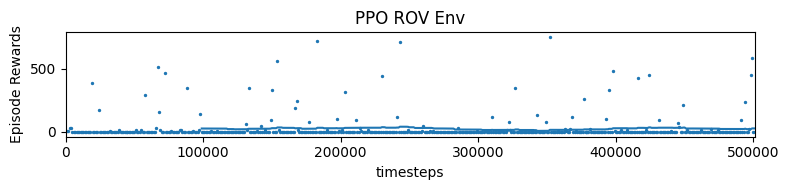

In [65]:
from stable_baselines3.common import results_plotter

results_plotter.plot_results([log_dir], 1000000, results_plotter.X_TIMESTEPS, "PPO ROV Env")
plt.show()

In [66]:
import pandas as pd

df = pd.read_csv("./logsV3" + "/monitor.csv", comment="#")
print(df["r"].describe())

count    503.000000
mean      26.359403
std       97.712306
min        0.010884
25%        0.014844
50%        0.017151
75%        0.632120
max      748.815975
Name: r, dtype: float64


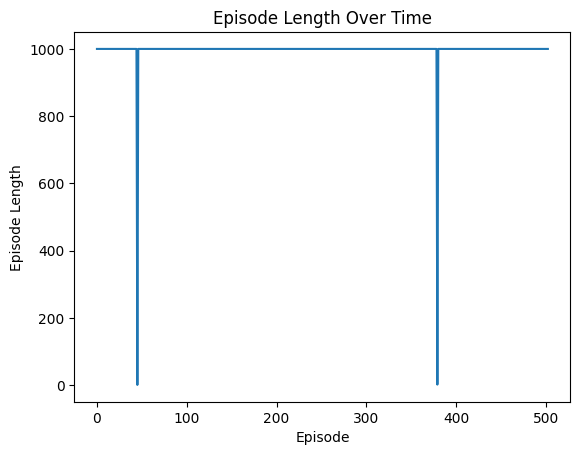

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./logsV3/monitor.csv", skiprows=1)

plt.plot(df["l"])
plt.xlabel("Episode")
plt.ylabel("Episode Length")
plt.title("Episode Length Over Time")
plt.show()

In [11]:
#__credits__ = ["Kallinteris-Andreas", "Rushiv Arora"]
# https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/mujoco/swimmer_v5.py referenced

import numpy as np

from gymnasium import utils
from gymnasium.envs.mujoco import MujocoEnv
from gymnasium.spaces import Box


class ROVEnvV4(MujocoEnv, utils.EzPickle):

    metadata = {
        "render_modes": [
            "human",
            "rgb_array",
            "depth_array",
            "rgbd_tuple",
        ],
    }

    def __init__(
        self,
        xml_file: str = "rovV2.xml",
        frame_skip: int = 4,
        default_camera_config: dict[str, float | int] = None,
        distance_reward_weight: float = 1.0,
        energy_cost_weight: float = 1e-4,
        reset_noise_scale: float = 0.1,
        **kwargs,
    ):
        utils.EzPickle.__init__(
            self,
            xml_file,
            frame_skip,
            default_camera_config,
            distance_reward_weight,
            energy_cost_weight,
            reset_noise_scale,
            **kwargs,
        )

        self.distance_reward_weight = distance_reward_weight
        self.energy_cost_weight = energy_cost_weight

        self._reset_noise_scale = reset_noise_scale

        MujocoEnv.__init__(
            self,
            xml_file,
            frame_skip,
            observation_space=None,
            default_camera_config=default_camera_config,
            **kwargs,
        )

        self.metadata = {
            "render_modes": [
                "human",
                "rgb_array",
                "depth_array",
                "rgbd_tuple",
            ],
            "render_fps": int(np.round(1.0 / self.dt)),
        }

        obs_size = 4
        
        self.observation_space = Box(
            low=-np.inf, high=np.inf, shape=(obs_size,), dtype=np.float64
        )

        self.observation_structure = {
            "distance_to_goal": 2,
            "velocity": 2,
        }

    def step(self, action):  
        xy_position_before = self.data.qpos[0:2].copy()
        self.do_simulation(action, self.frame_skip)
        xy_position_after = self.data.qpos[0:2].copy()

        xy_velocity = (xy_position_after - xy_position_before) / self.dt
        x_velocity, y_velocity = xy_velocity

        observation = self.get_observation()
        
        reward, reward_info = self.get_reward(xy_position_after, action)
        info = {
            "x_position": xy_position_after[0],
            "y_position": xy_position_after[1],
            "distance_from_origin": np.linalg.norm(xy_position_after, ord=2),
            "x_velocity": x_velocity,
            "y_velocity": y_velocity,
            **reward_info,
        }

        if self.render_mode == "human":
            self.render()

        distance_to_goal = np.linalg.norm(observation[0:2])
        if distance_to_goal < 0.25:
            terminated = True
        else:
            terminated = False

        self.step_count += 1
        if self.step_count >= 1000:
            truncated = True
        else:
            truncated = False

        return observation, reward, terminated, truncated, info

    def get_reward(self, position, action):
        distance_from_goal = self.goal_position - position
        euclidean_dist_from_goal = np.linalg.norm(distance_from_goal)
        distance_reward = self.distance_reward_weight * np.exp(-np.linalg.norm(distance_from_goal)**2)
        energy_reward = self.energy_cost_weight * np.exp(-np.linalg.norm(action)**2)
        reward_bonus = 0

        if euclidean_dist_from_goal < 0.5:
            reward_bonus += 1

        total_reward = distance_reward + energy_reward + reward_bonus

        reward = total_reward

        reward_info = {
            "distance_reward": distance_reward,
            "energy_reward": energy_reward,
            "total_reward": total_reward,
        }

        return reward, reward_info

    def get_observation(self):
        position = self.data.qpos[0:2]
        distance_to_goal = self.goal_position - position
        velocity = self.data.qvel[0:2]

        observation = np.concatenate([distance_to_goal, velocity]).ravel()
        return observation

    def reset_model(self):
        self.step_count = 0
        
        noise_low = -self._reset_noise_scale
        noise_high = self._reset_noise_scale

        qpos = self.init_qpos + self.np_random.uniform(
            low=noise_low, high=noise_high, size=self.model.nq
        )
        qvel = self.init_qvel + self.np_random.uniform(
            low=noise_low, high=noise_high, size=self.model.nv
        )

        self.set_state(qpos, qvel)

        self.goal_position = self.np_random.uniform(low=-2, high=2, size=(2, ))
        print(self.goal_position)

        observation = self.get_observation()
        return observation

    def get_reset_info(self):
        return {
            "x_position": self.data.qpos[0],
            "y_position": self.data.qpos[1],
            "distance_from_origin": np.linalg.norm(self.data.qpos[0:2], ord=2),
            "current_goal": self.goal_position,
        }

In [ ]:
import os
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor


log_dir = "./logsV4/"
os.makedirs(log_dir, exist_ok=True)


env = ROVEnvV4(xml_file="/home/charstieve/cs4180/rovV2.xml")
check_env(env)
env = Monitor(env, log_dir)

model = PPO(
    "MlpPolicy",
    env,
    learning_rate=1e-3,
    n_steps=4096,
    clip_range=0.1,
    vf_coef=0.2,
    verbose=1
)
model.learn(total_timesteps=500_000)
model.save("rov_ppo_v3")

[1.25308096 1.65102231]
[ 1.26341422 -1.989046  ]
[1.45271569 0.16584488]
Using cpu device
Wrapping the env in a DummyVecEnv.
[0.68249766 0.58875805]
[0.74216794 0.60183711]
[ 0.10141729 -0.7590325 ]
[ 0.28611932 -0.71252244]
[-1.09136963  0.49274858]
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | 489      |
| time/              |          |
|    fps             | 4502     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 4096     |
---------------------------------
[ 1.50593692 -1.76572786]
[-1.07743116 -1.7919148 ]
[-0.80521547  0.68797951]
[0.51643261 1.70861821]
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1e+03        |
|    ep_rew_mean          | 315          |
| time/                   |              |
|    fps                  | 2437         |
|    iterations           | 2            |
|    

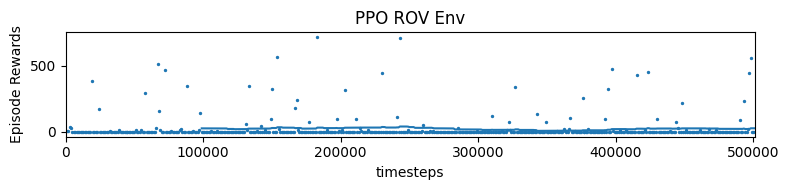

In [76]:
from stable_baselines3.common import results_plotter

results_plotter.plot_results(["./logsV4/"], 1000000, results_plotter.X_TIMESTEPS, "PPO ROV Env")
plt.show()

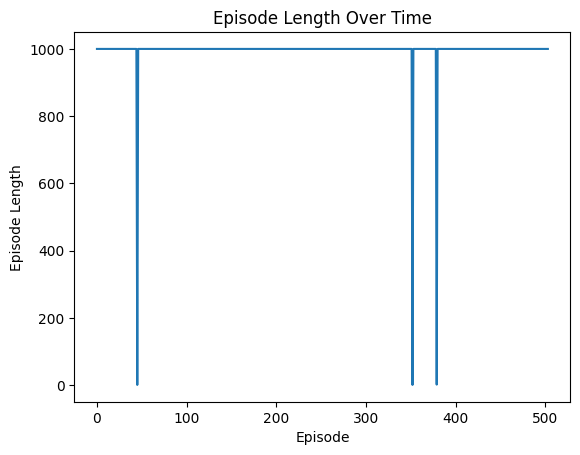

In [78]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./logsV4/monitor.csv", skiprows=1)

plt.plot(df["l"])
plt.xlabel("Episode")
plt.ylabel("Episode Length")
plt.title("Episode Length Over Time")
plt.show()

In [80]:
import pandas as pd

df = pd.read_csv("./logsV4" + "/monitor.csv", comment="#")
print(df["r"].describe())

count    504.000000
mean      24.724852
std       91.930972
min        0.011063
25%        0.014887
50%        0.017544
75%        0.617880
max      718.127003
Name: r, dtype: float64
